  # Water Quality Dataset — EDA & Preprocessing
  ### Assignment: Analytics Vidhya DL with PyTorch
  **Tasks:**
  - Regression → Predict WQI (Water Quality Index)
  - Classification → Predict Water Quality Category


In [4]:
#!pip install seaborn

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import pickle
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)

In [6]:
df = pd.read_csv('water_quality.csv')
print("Shape:", df.shape)
df.head()

Shape: (19029, 24)


,Well_ID,State,District,Block,Village,Latitude,Longitude,Year,pH,EC,CO3,HCO3,Cl,SO4,NO3,TH,Ca,Mg,Na,K,F,TDS,WQI,Water Quality Classification
0,W232200071580001,Gujarat,Ahmedabad,Mandal,Dalod,NaN,NaN,2020,8.20,16640.0,0.0,1257.0,5176.0,822.0,26.00,1451.0,152.0,260.0,3535.0,45.0,1.00,11149,4361.44080,Unsuitable for Drinking
1,W254029084355301,Himachal Pradesh,Solan,Nallagarh,JAGATPUR,31.1594,76.678500,2019,8.44,299.0,43.0,87.0,21.0,0.0,2.70,84.0,17.0,10.0,39.0,2.4,0.20,262,85.80466,Good
2,W193530074180001,Maharashtra,Ahmednagar,SANGAMNER,Kokangaon,74.3000,19.591667,2022,7.90,1315.0,0.0,518.7,120.5,61.6,18.20,465.0,80.2,64.4,88.3,1.6,0.53,372,280.04130,Very Poor yet Drinkable
3,W231620072033001,Gujarat,Ahmedabad,Viramgam,Endla,NaN,NaN,2020,7.40,715.0,0.0,354.0,50.0,18.0,0.23,280.0,56.0,34.0,47.0,11.0,0.46,479,195.11649,Poor
4,W251908084361501,Himachal Pradesh,Solan,Nallagarh,BARUNA,31.1540,76.638400,2019,8.40,270.0,43.0,87.0,14.0,0.0,10.00,116.0,10.0,18.0,23.0,1.0,0.12,262,81.77860,Good


In [7]:
  print("=== Column Types ===")
  print(df.dtypes)
  print("\n=== Missing Values ===")
  print(df.isnull().sum())

=== Column Types ===
Well_ID                             str
State                               str
District                            str
Block                               str
Village                             str
Latitude                        float64
Longitude                       float64
Year                              int64
pH                              float64
EC                              float64
CO3                             float64
HCO3                            float64
Cl                              float64
SO4                             float64
NO3                             float64
TH                              float64
Ca                              float64
Mg                              float64
Na                              float64
K                               float64
F                               float64
TDS                               int64
WQI                             float64
Water Quality Classification        str
dtype: object

=== 

In [9]:
print("=== WQI Stats ===")
print(df['WQI'].describe())

print("\n=== Classification Counts ===")
print(df['Water Quality Classification'].value_counts())

=== WQI Stats ===
count    19029.000000
mean       305.291789
std        315.477116
min          9.043604
25%        146.642420
50%        232.078880
75%        359.718240
max       6850.888720
Name: WQI, dtype: float64

=== Classification Counts ===
Water Quality Classification
Unsuitable for Drinking    6608
Poor                       5317
Very Poor yet Drinkable    4709
Good                       1632
Excellent                   763
Name: count, dtype: int64


This output is a statistical summary of a Water Quality Index (WQI) dataset, generated using Python's pandas library (.describe()). It analyzes 19,029 unique water samples.
The data shows a heavily skewed distribution where most water samples have relatively low WQI scores, but a few extreme, abnormally high pollution spikes pull up the overall statistical average.
## Line-by-Line Breakdown

* count: 19029.00
* What it means: There are exactly 19,029 valid data points (water quality readings) in this dataset.
* mean: 305.29
* What it means: The arithmetic average of all WQI readings is 305.29.
* std: 315.48
* What it means: The standard deviation is 315.48. This tells us the data is highly spread out from the average. A standard deviation larger than the mean is a major indicator of extreme variability. [1] 
* min: 9.04
* What it means: The single cleanest or lowest WQI reading recorded is 9.04.
* 25%: 146.64 (First Quartile / Q₁)
* What it means: 25% of all water samples have a WQI score of 146.64 or lower.
* 50%: 232.08 (Median / Q₂)
* What it means: This is the true middle of your data. Exactly half of the samples are below 232.08, and half are above it.
* 75%: 359.72 (Third Quartile / Q₃)
* What it means: 75% of all water samples have a WQI score of 359.72 or lower. Only 25% of the samples are higher than this.
* max: 6850.89
* What it means: The single highest, most polluted WQI score recorded is a massive 6850.89.

## Key Conclusions & "The Big Picture"

   1. Severe Right Skew (Positive Skew): In a perfectly balanced dataset, the mean and the median are roughly equal. In your data, the mean (305.29) is significantly higher than the median (232.08). This happens because a few astronomically high numbers are dragging the average upward. [2] 
   2. The "Normal" Range: The core of your dataset is actually quite compact. The middle 50% of your water samples live strictly between 146.64 and 359.72 (an IQR of 213.08).
   3. Massive Outlier Anomalies: The maximum value of 6850.89 is nearly 19 times higher than your 75th percentile. Statistically, anything over 679.33 is an outlier in this dataset. This means you have a collection of extreme spikes—potentially caused by industrial dumping events, severe weather runoff, or data logging errors—that need to be isolated.



To find the 75% mark (Third Quartile / \(Q_{3}\)), pandas performs the following hidden operations:Sorts the Entire Dataset: It takes all 19,029 water samples and ranks them in a single line from the lowest WQI score (9.04) up to the highest (6,850.89).Finds the 75% Cutoff Position: It calculates exactly where the 75% mark falls in that sorted line:\(19,029\times 0.75=14,271.75\)Identifies the Value: It looks at the 14,272nd sample in that sorted line. The physical WQI score sitting at that exact position is 359.72.

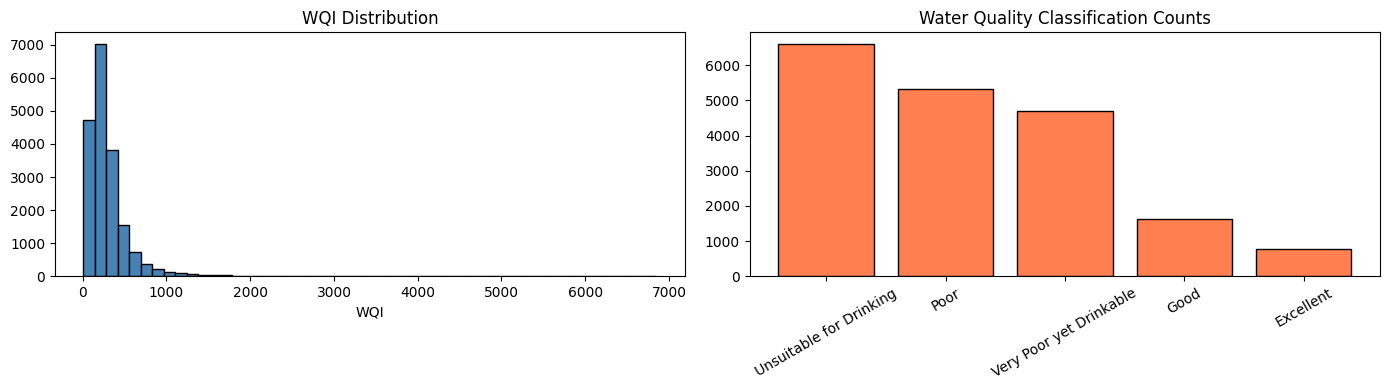

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['WQI'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('WQI Distribution')
axes[0].set_xlabel('WQI')

counts = df['Water Quality Classification'].value_counts()
axes[1].bar(counts.index, counts.values, color='coral', edgecolor='black')
axes[1].set_title('Water Quality Classification Counts')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

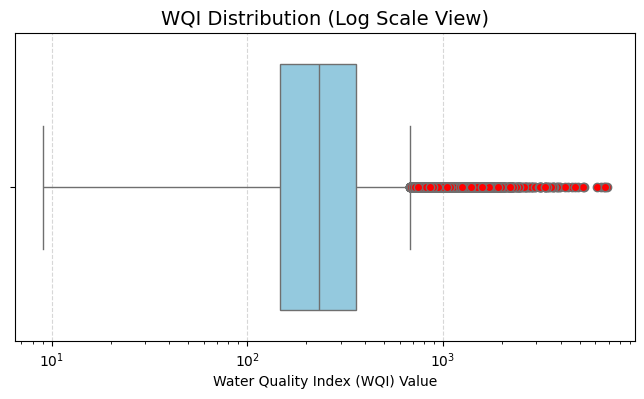

In [12]:
# Recreating a representative distribution matching your exact summary stats
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['WQI'], color="skyblue", flierprops={"markerfacecolor":"red", "marker":"o"})

# Crucial step: Set to log scale because max (6850) squashes the box (232)
plt.xscale('log')

plt.title('WQI Distribution (Log Scale View)', fontsize=14)
plt.xlabel('Water Quality Index (WQI) Value')
plt.grid(axis='x', linestyle='--', alpha=0.5)

In [13]:
# Drop identifiers — not useful for prediction
drop_cols = ['Well_ID', 'District', 'Block', 'Village']
df = df.drop(columns=drop_cols)

# Fill missing Latitude/Longitude with median
df['Latitude'] = df['Latitude'].fillna(df['Latitude'].median())
df['Longitude'] = df['Longitude'].fillna(df['Longitude'].median())

print("Shape after cleaning:", df.shape)
print("Remaining missing values:\n", df.isnull().sum())

Shape after cleaning: (19029, 20)
Remaining missing values:
 State                           0
Latitude                        0
Longitude                       0
Year                            0
pH                              0
EC                              0
CO3                             0
HCO3                            0
Cl                              0
SO4                             0
NO3                             0
TH                              0
Ca                              0
Mg                              0
Na                              0
K                               0
F                               0
TDS                             0
WQI                             0
Water Quality Classification    0
dtype: int64


In [14]:
# One-hot encode State
df = pd.get_dummies(df, columns=['State'], drop_first=True)
print("Shape after encoding State:", df.shape)

Shape after encoding State: (19029, 32)


In [16]:
le = LabelEncoder()
df['WQ_Encoded'] = le.fit_transform(df['Water Quality Classification'])
print("Class mapping:")
for i, cls in enumerate(le.classes_):
  print(f"  {i} → {cls}")

Class mapping:
  0 → Excellent
  1 → Good
  2 → Poor
  3 → Unsuitable for Drinking
  4 → Very Poor yet Drinkable


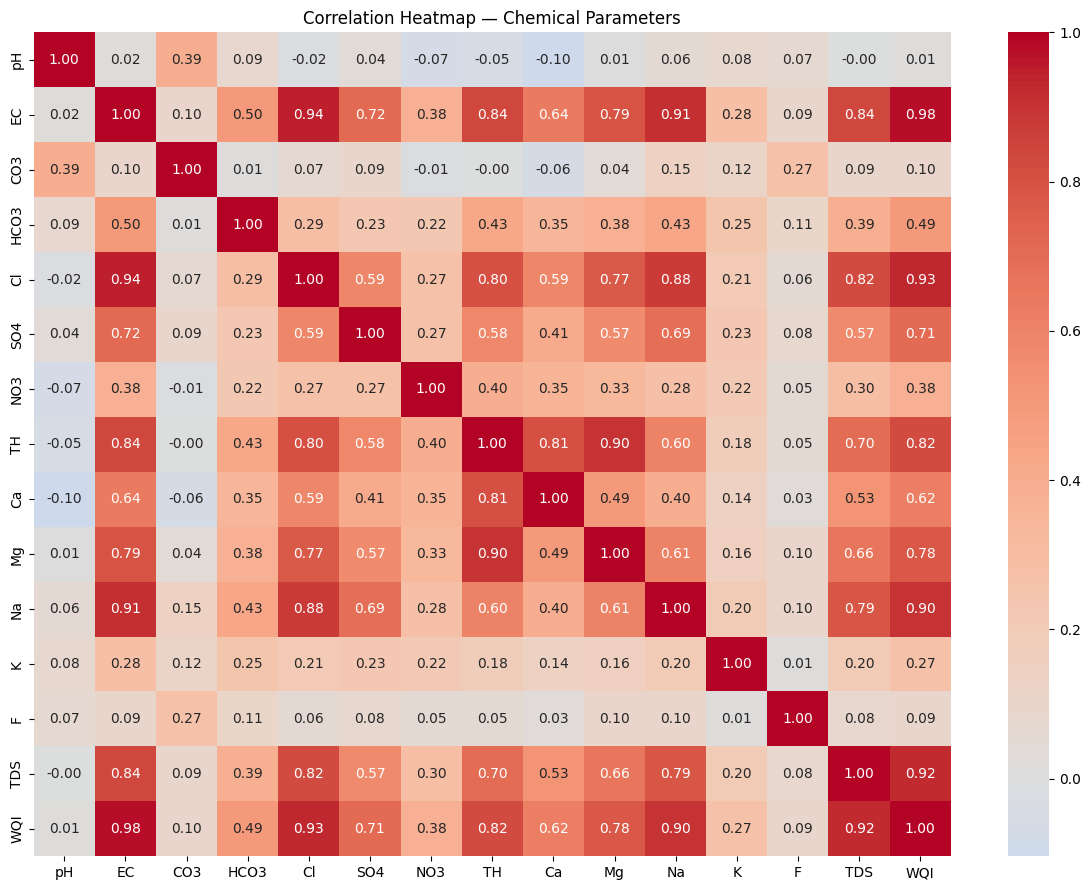

In [17]:
# Only numeric chemistry columns
chem_cols = ['pH', 'EC', 'CO3', 'HCO3', 'Cl', 'SO4', 'NO3', 'TH', 'Ca', 'Mg', 'Na', 'K', 'F', 'TDS',
'WQI']

plt.figure(figsize=(12, 9))
sns.heatmap(df[chem_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Chemical Parameters')
plt.tight_layout()
plt.show()


In [18]:
# Drop the string target column — we use the encoded version
TARGET_REG = 'WQI'
TARGET_CLF = 'WQ_Encoded'

drop_for_X = ['WQI', 'Water Quality Classification', 'WQ_Encoded']
X = df.drop(columns=drop_for_X)
y_reg = df[TARGET_REG]     # regression target
y_clf = df[TARGET_CLF]     # classification target

print("X shape:", X.shape)
print("y_reg shape:", y_reg.shape)
print("y_clf shape:", y_clf.shape)

X shape: (19029, 30)
y_reg shape: (19029,)
y_clf shape: (19029,)


In [19]:
#Scale Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Feature scaling done. Sample mean (should be ~0):", X_scaled.mean().mean().round(4))

Feature scaling done. Sample mean (should be ~0): 0.0


In [21]:
X_train, X_test, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
  X_scaled, y_reg, y_clf,
  test_size=0.2,
  random_state=42
)

print("Train size:", X_train.shape)
print("Test size :", X_test.shape)

Train size: (15223, 30)
Test size : (3806, 30)


In [22]:
# Save everything to a pickle file so each algorithm notebook loads it directly
data = {
  'X_train': X_train,
  'X_test': X_test,
  'y_reg_train': y_reg_train,
  'y_reg_test': y_reg_test,
  'y_clf_train': y_clf_train,
  'y_clf_test': y_clf_test,
  'feature_names': list(X.columns),
  'label_encoder': le,
  'scaler': scaler
}

with open('processed_data.pkl', 'wb') as f:
  pickle.dump(data, f)

print("Saved processed_data.pkl — all algorithm notebooks will load this.")


Saved processed_data.pkl — all algorithm notebooks will load this.


## Preprocessing Summary

  | Step | Action |
  |------|--------|
  | Dropped columns | Well_ID, District, Block, Village |
  | Missing values | Latitude/Longitude filled with median |
  | Categorical encoding | State → one-hot, Classification → LabelEncoder |
  | Feature scaling | StandardScaler (mean=0, std=1) |
  | Train/Test split | 80% / 20%, random_state=42 |